In [1]:
import lsst.afw.image as afwImage
import matplotlib.pyplot as plt
import numpy as np
import csv
import pandas as pd
from astropy.io import ascii
import skyproj

In [7]:
path = "/sdf/data/rubin/repo/main/DECam/communityProcessed/decade_coadds/taiga/deca_archive/DEC/multiepoch/delve/r6050/DES0945-3914/p01/coadd/DES0945-3914_r6050p01_r.fits.fz"

In [8]:
exp = afwImage.ExposureF
w = exp.readFits(path)

In [9]:
np.nanpercentile(w.image.array,(10,90))

array([-7.87552886, 12.02921305])

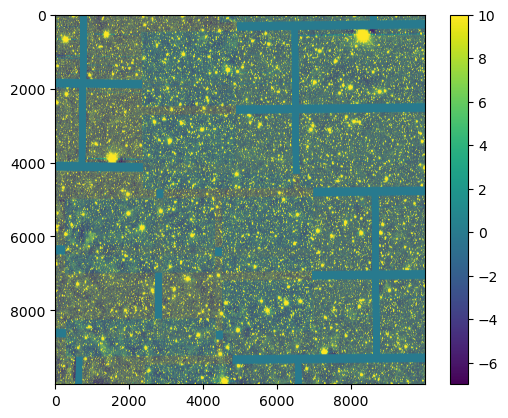

In [10]:
plt.imshow(w.image.array,vmin=-7,vmax=10)
plt.colorbar()
plt.show()

In [12]:
w.getMetadata()

TTYPE1 = "COMPRESSED_DATA"
// label for field   1
TFORM1 = "1PB(8626)"
// data format of field: variable length array
TTYPE2 = "ZSCALE"
// label for field   2
TFORM2 = "1D"
// data format of field: 8-byte DOUBLE
TTYPE3 = "ZZERO"
// label for field   3
TFORM3 = "1D"
// data format of field: 8-byte DOUBLE
EXTNAME = "SCI"
GAIN = 7.6654312047110
// Maximum equivalent gain (e-/ADU)
SATURATE = 34463.112109670
// Saturation Level (ADU)
SOFTNAME = "SWarp"
// The software that processed those data
SOFTVERS = "2.40.1"
// Version of the software
SOFTDATE = "2021-07-09"
// Release date of the software
SOFTAUTH = "2010-2012 IAP/CNRS/UPMC"
// Maintainer of the software
SOFTINST = "IAP  http://www.iap.fr"
// Institute
AUTHOR = "unknown"
// Who ran the software
ORIGIN = "ccc0012.campuscluster.illinois.edu"
// Where it was done
DATE = "2023-01-24T11:29:26"
// When it was started (GMT)
COMBINET = "WEIGHTED"
// COMBINE_TYPE config parameter for SWarp
COMMENT = [ " Propagated FITS keywords", " Axis-depend

In [13]:
w.getBBox()

Box2I(corner=Point2I(0, 0), dimensions=Extent2I(10000, 10000))

## Butler command to ingest files

In [14]:
import lsst.daf.butler as daf_butler
from astropy.coordinates import SkyCoord
from astropy import units as u
import lsst.geom as geom
import os
import astropy.table as table

In [15]:
but = daf_butler.Butler("/repo/main")

In [16]:
but.registry.queryDatasetTypes("des_coadd")

[DatasetType('des_coadd', {band, skymap, tract}, ExposureF)]

In [20]:
REPO = "/repo/main"
DATASET_TYPE = "template_coadd"
RUN = "/DECam/DELVE/DR3/coadds"
TABLE_FILE = "tableFile.csv"

In [21]:
def makeCLIQuery(repo,datasetType,run,tableFile):
    return "butler ingest-files {} {} {} {}".format(repo,datasetType,run,tableFile)

In [22]:
makeCLIQuery(REPO,DATASET_TYPE,RUN,TABLE_FILE)

'butler ingest-files /repo/main template_coadd /DECam/DELVE/DR3/coadds tableFile.csv'

In [179]:
tab = table.Table()
skymaps = but.registry.queryDatasets("skyMap",collections='DECam/defaults')
decamSkymap_ringsv1 = list(skymaps)[2]
result = but.get(decamSkymap_ringsv1)

In [180]:
fnames = np.array(["DES0301-0458_r6450p01_g.fits.fz","DES0301-0458_r6450p01_i.fits.fz","DES0301-0458_r6450p01_r.fits.fz","DES0301-0458_r6450p01_z.fits.fz"])
ra, dec = fnames[0][0:12][3:7],fnames[0][0:12][7:] # The hhmm and ddmm form of ra and dec
    
ra_h = int(ra[0:2]) # string stripping
ra_m = int(ra[2:])
dec_deg = int(dec[1:3])
dec_m = int(dec[3:])
offset = dec[0] # computing if dec is +/- the equator

finalRa = (ra_h*15+ra_m/60)*u.deg # final RA

if offset=="-": # final DEC
    finalDec = -1 * (dec_deg+dec_m/60)*u.deg
else: 
    finalDec = (dec_deg+dec_m/60)*u.deg

coord=SkyCoord(finalRa,finalDec,frame="icrs")

In [181]:
DESCMP2_pathList = pd.read_csv("fullPathList_fz.txt",names=["fname"])

def getCoordFromTilename(tileName):
    ra, dec = tileName[3:7],tileName[7:] # The hhmm and ddmm form of ra and dec

    # print("ra, dec: {} {}".format(ra,dec))
    
    ra_h = int(ra[0:2]) # string stripping
    ra_m = int(ra[2:])
    dec_deg = int(dec[1:3])
    dec_m = int(dec[3:])
    offset = dec[0] # computing if dec is +/- the equator
    
    finalRa = 15*(ra_h+ra_m/60)*u.deg # final RA
    
    if offset=="-": # final DEC
        finalDec = -1 * (dec_deg+dec_m/60)*u.deg
    else: 
        finalDec = (dec_deg+dec_m/60)*u.deg

    
    return SkyCoord(finalRa,finalDec,frame="icrs")

In [233]:
baseDir = "/sdf/group/rubin/repo/main/DECam/communityProcessed/decade_coadds"

dataArr = []

tileCoords = []

for localPath in DESCMP2_pathList['fname']:

    fullPath = baseDir+localPath

    tileName = fullPath.split("/")[-4]
    
    # subDirFiles = np.array(os.listdir(os.path.join(baseDir,subDir)))
    
    # msk = [(x.endswith(".fits.fz") and not (x.__contains__("nobkg") or x.__contains__("det"))) for x in subDirFiles]
    # msk = [(x.endswith(".fits.fz") and x.__contains__("nobkg") and not x.__contains__("det")) for x in subDirFiles]
    
    # filteredFiles = np.array(subDirFiles)[msk]
    
    coord=getCoordFromTilename(tileName)

    tractInf,patchInf = result.findClosestTractPatchList([geom.SpherePoint(geom.Angle(coord.ra.deg/(180/np.pi)),geom.Angle(coord.dec.deg/(180/np.pi)))])[0]
    
    band = fullPath.split("/")[-1].split(".")[0].split("_")[-1].lower()

    dataArr.append([fullPath,band,str(decamSkymap_ringsv1.dataId["skymap"]),tractInf.getId(),patchInf[0].getSequentialIndex()])
    # tileCoords.append(coord)


KeyboardInterrupt



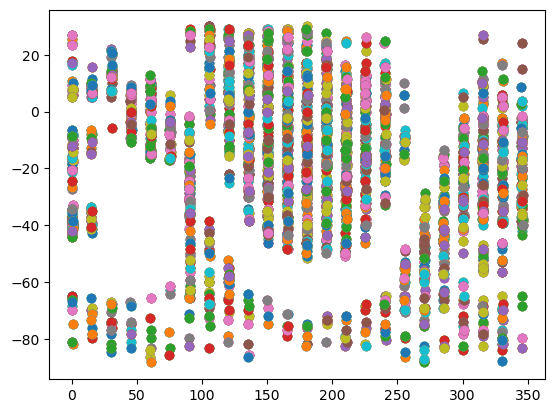

In [211]:
fig,ax = plt.subplots()


for cord in np.array(tileCoords):
    # coords = getCoordsFromTractPatch(t_p[0],t_p[1])
    ax.scatter(cord.ra.deg,cord.dec.deg)
plt.show()

In [208]:
fig, ax = plt.subplots(figsize=(8, 10))
sp = skyproj.McBrydeSkyproj(ax=ax,lon_0=180)

for cord in np.array(tileCoords):
    # coords = getCoordsFromTractPatch(t_p[0],t_p[1])
    sp.scatter(cord.ra.deg,cord.dec.deg)

sp.draw_milky_way(label='Milky way +/- 10 deg')
plt.show()

KeyboardInterrupt: 

In [234]:
dataDF = pd.DataFrame(np.array(dataArr),columns=["filename","band","skymap","tract","patch"])
band_tract_patch = dataDF["band"]+"_"+dataDF["tract"]+"_"+dataDF['patch']
uniq_band_tract_patch,indices,counts = np.unique(band_tract_patch,return_index=True,return_counts=True)
dataDF.iloc[indices].to_csv(TABLE_FILE,index=False,header=True)

In [117]:
table = ascii.read(TABLE_FILE)

In [191]:
result.findClosestTractPatchList([geom.SpherePoint(geom.Angle(coord.ra.deg/(180/np.pi)),geom.Angle(coord.dec.deg/(180/np.pi)))])[0]

(TractInfo(id=2131, ctrCoord=[-0.6249386674680185, 7.653291387781211e-17, -0.780673851171728]),
 (PatchInfo(index=Index2D(x=2, y=2), innerBBox=(minimum=(8000, 8000), maximum=(11999, 11999)), outerBBox=(minimum=(7900, 7900), maximum=(12099, 12099))),))

In [185]:
getCoordFromTilename(tileName)

<SkyCoord (ICRS): (ra, dec) in deg
    (180.16666667, -51.38333333)>

In [195]:
result.findTractPatchList([geom.SpherePoint(geom.Angle(coord.ra.deg/(180/np.pi)),geom.Angle(coord.dec.deg/(180/np.pi)))])[0]

(TractInfo(id=2131, ctrCoord=[-0.6249386674680185, 7.653291387781211e-17, -0.780673851171728]),
 (PatchInfo(index=Index2D(x=2, y=2), innerBBox=(minimum=(8000, 8000), maximum=(11999, 11999)), outerBBox=(minimum=(7900, 7900), maximum=(12099, 12099))),))

In [232]:


getCoordFromTilename("DES0017-4123")

<SkyCoord (ICRS): (ra, dec) in deg
    (4.25, -41.38333333)>

In [213]:
RA_CENT = 4.4455836881963
# // RA center
DEC_CENT = -41.388925527767
# // DEC center

## Now, what command should be entered to ingest this data?

In [157]:
but.registry.queryDatasetTypes("template_coadd")

[DatasetType('template_coadd', {band, skymap, tract, patch}, ExposureF)]

In [158]:
test = list(but.registry.queryDatasets("template_coadd",collections="/DECam/DECADE/coadds",where="skymap='decam_rings_v1'"))

In [159]:
exp = but.get(test[0])

IndexError: list index out of range

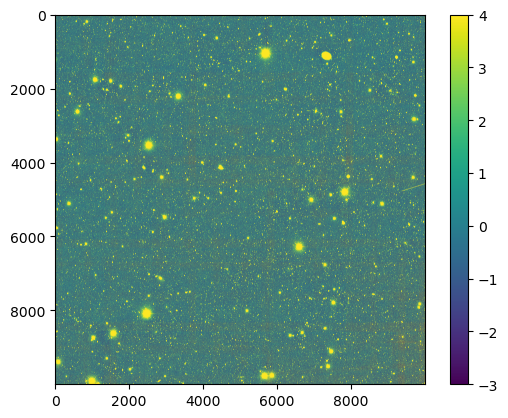

In [138]:
plt.imshow(exp.image.array,vmin=-3,vmax=4)
plt.colorbar()
plt.show()